<a href="https://colab.research.google.com/github/kayurh/data_analytics/blob/main/5_2_lecture_Kayur_Amour_Harry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 5.2 – Scaling and Normalization 2. (Row-wise normalization / Normalizer)

In notebook 5.1 we saw that **scaling** is important because when variables have different measurement units and ranges, an analysis (e.g., distance, similarity) can easily become “distorted” due to a dominant scale.

In this notebook the focus is on **row-wise normalization**.

- Normalization does not transform the distribution of variables (columns), but instead treats each **observation (row)** separately.
- Its goal is that comparisons between observations are determined **not by magnitude**,  
  but by the **ratios / composition** within each observation.
- In other words, normalization “removes size” from the rows and focuses on **how the variables are distributed** within an observation.

In the notebook we first demonstrate with a simple 2D example what row-wise normalization means in a geometric sense, then using the **Penguins** dataset we examine, for a concrete question, when it is better to use scaling and when normalization.

### Row-wise scaling (Normalizer)

- During normalization, the data are transformed **row-wise** so that the (geometric) length of each observation vector becomes **1**.
- In this case, **we do not scale the distribution of variables (columns)**, but instead treat each observation (row) separately.
- The method examines **in what proportions the variables appear within a given observation**.
- The goal is therefore not the comparability of distributions (as in the case of `StandardScaler`), but ensuring that the **magnitude of observations does not influence the comparison**.

### Let us look at a simple example to understand normalization

- Let us create two points that we imagine in a **2-dimensional space**.
- Each point represents an **observation**, and the two coordinates represent two **variables (features)**.
- During normalization, we will examine how the positions of the points change
  if the lengths of the vectors are **scaled to 1**.

In [ ]:
import pandas as pd
# Create two points in a 2-dimensional space
df_xy = pd.DataFrame({
    "x": [10, 100],
    "y": [10, 100]
})

df_xy

,x,y
0,10,10
1,100,100


Plot the points.



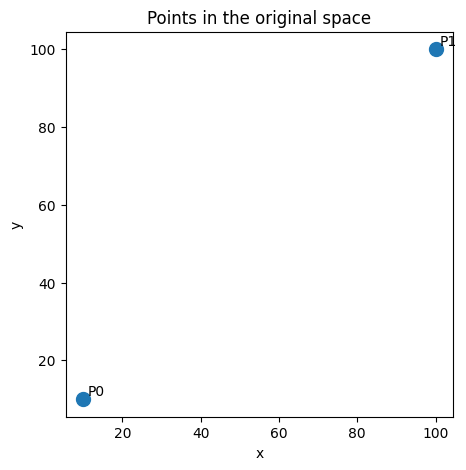

In [ ]:
import matplotlib.pyplot as plt

# Create a square figure
plt.figure(figsize=(5, 5))

# Plot the points based on the x and y coordinates
plt.scatter(df_xy["x"], df_xy["y"], s=100)

# Label the points
for i in df_xy.index:
    plt.text(df_xy.loc[i, "x"] + 1, df_xy.loc[i, "y"] + 1, f"P{i}")

# Set axis labels and title
plt.xlabel("x")
plt.ylabel("y")
plt.title("Points in the original space")

# Display the figure
plt.show()

Let us compute the **Euclidean distance** between the two points.

This shows how far the two points are from each other
in a 2-dimensional space – as if we measured their distance with a ruler.

In [ ]:
import numpy as np

# Read the coordinates of the two points
x1, y1 = df_xy.loc[0]
x2, y2 = df_xy.loc[1]

# Compute the Euclidean distance
distance = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

distance

np.float64(127.27922061357856)

Now let us try to **normalize the data row-wise**.

During normalization, each observation is divided by its own
**vector length (L2 norm)**.  
This way each row becomes a vector with **length 1**.

First, we compute this **manually**, without using scikit-learn.

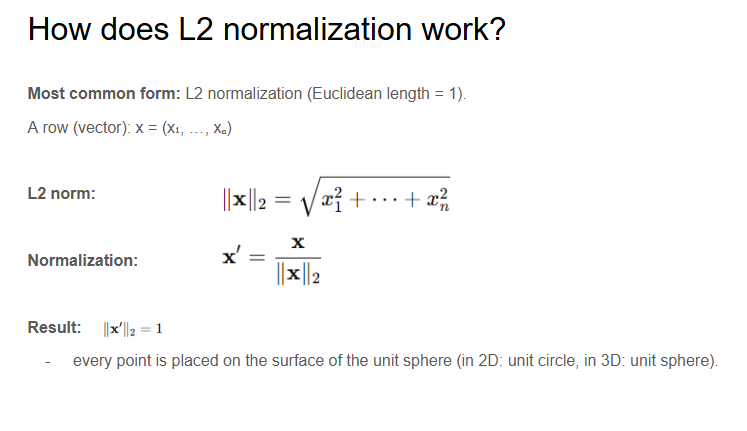

In [ ]:
# Compute row-wise vector length (L2 norm)
row_norm = np.sqrt(df_xy["x"]**2 + df_xy["y"]**2)

# Normalization: divide each element by the length of its own row
df_xy_normalized = df_xy.div(row_norm, axis=0)

df_xy_normalized

,x,y
0,0.707107,0.707107
1,0.707107,0.707107


In [ ]:
# Let us examine the vector lengths.
row_norm

,0
0,14.142136
1,141.421356


### What can we observe?

- The second point is simply a **10× larger** vector pointing in the **same direction**  
  (the two points are **scalar multiples** of each other).
- Therefore, after normalization the two points **end up at the same location**.

The same solution using the built-in scikit-learn transformer, which can be trained and saved in a pipeline.

In [ ]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()

df_xy_norm = pd.DataFrame(
    normalizer.fit_transform(df_xy),
    columns=["x","y"]
)

df_xy_norm

,x,y
0,0.707107,0.707107
1,0.707107,0.707107


After normalization, the points **end up in the same direction**, because the two original points were scalar multiples of each other.

The difference was in their magnitude, which normalization removes, so the two points practically **fall to the same location**.

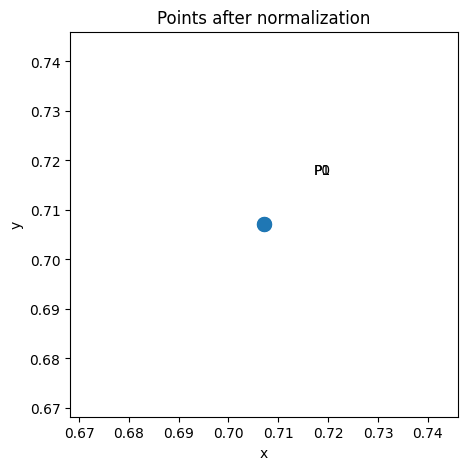

In [ ]:
# Create a square figure
plt.figure(figsize=(5, 5))

# Plot the normalized points based on the x and y coordinates
plt.scatter(df_xy_norm["x"], df_xy_norm["y"], s=100)

# Label the points
for i in df_xy_norm.index:
    plt.text(df_xy_norm.loc[i, "x"] + 0.01, df_xy_norm.loc[i, "y"] + 0.01, f"P{i}")

# Set axis labels and title
plt.xlabel("x")
plt.ylabel("y")
plt.title("Points after normalization")

# Display the figure
plt.show()

Let us compute again the **Euclidean distance** between the two points after normalization.

In [ ]:
x1, y1 = df_xy_norm.loc[0]
x2, y2 = df_xy_norm.loc[1]

distance_norm = np.sqrt((x2-x1)**2 + (y2-y1)**2)

distance_norm

np.float64(0.0)

**Observation**

- In the original space, the two points are far from each other,
  because one point contains larger values.

- After normalization, however, the two points become **vectors pointing
  in the same direction**, so their distance becomes **0**.

- Normalization therefore **removes the magnitude of observations**
  and retains only the **relative proportions** of the variables.


**Why is this useful?**

In many problems, the absolute values are not important,
but rather **the proportions** of variables within an observation.

For example:

- **Text mining**: a document may be longer or shorter,
  but the ratio or frequency pattern of words may be similar.

- **Recommender systems**: a strict and a lenient reviewer may give
  different scores, but the **relative evaluation** of movies may be similar.

- **Distance-based methods**: if a student is the best in the class
  in every subject, their relative performance remains similar
  even if in a difficult subject the highest grade is only a 3.

### Extra example: normalization does **not always** make the distance zero

In the previous example, the two points were **scalar multiples** of each other
(they pointed in the same direction), therefore after normalization they ended up at the same location.

Now let us look at two points that do **not** point in the same direction.

In [ ]:
# Two new points that are not scalar multiples
df_xy2 = pd.DataFrame({
    "x": [10, 100],
    "y": [100, 10]
})

# Distance in the original space
p0 = df_xy2.loc[0].values
p1 = df_xy2.loc[1].values
distance_original = np.linalg.norm(p1 - p0)

# Manual row-wise normalization
row_norm2 = np.linalg.norm(df_xy2.values, axis=1)
df_xy2_norm = df_xy2.div(row_norm2, axis=0)

# Distance after normalization
p0n = df_xy2_norm.loc[0].values
p1n = df_xy2_norm.loc[1].values
distance_after_norm = np.linalg.norm(p1n - p0n)

distance_original, distance_after_norm

(np.float64(127.27922061357856), np.float64(1.2664755805145254))

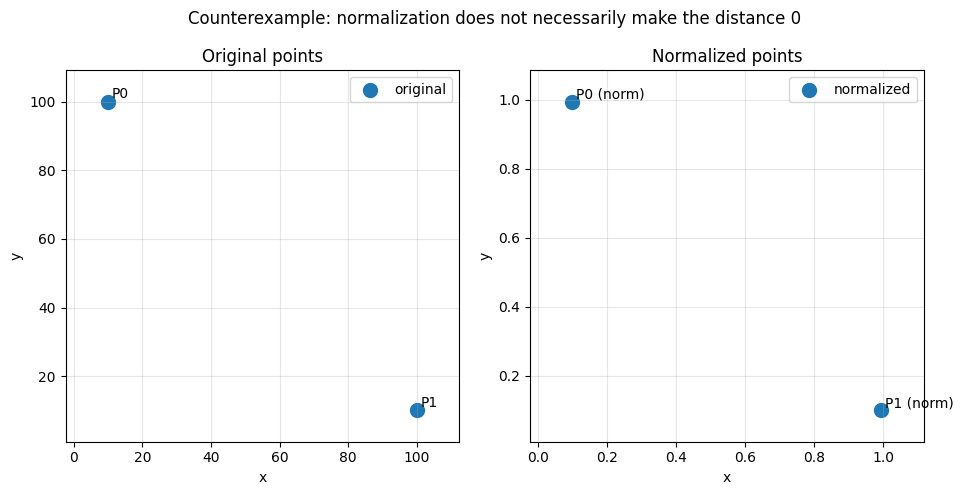

In [ ]:
import matplotlib.pyplot as plt

# Create two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# --- Original points ---
ax = axes[0]
ax.scatter(df_xy2["x"], df_xy2["y"], s=100, label="original")

for i in df_xy2.index:
    ax.text(df_xy2.loc[i, "x"] + 1, df_xy2.loc[i, "y"] + 1, f"P{i}")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Original points")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()


# --- Normalized points ---
ax = axes[1]
ax.scatter(df_xy2_norm["x"], df_xy2_norm["y"], s=100, label="normalized")

for i in df_xy2_norm.index:
    ax.text(df_xy2_norm.loc[i, "x"] + 0.01, df_xy2_norm.loc[i, "y"] + 0.01, f"P{i} (norm)")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Normalized points")
ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()


plt.suptitle("Counterexample: normalization does not necessarily make the distance 0")
plt.tight_layout()
plt.show()

**Conclusion:**

- The Normalizer **preserves the direction** of vectors but **removes their length**.  
- Therefore, the distance becomes 0 only if the two points **point in the same direction**.

### When should we use standardization and when normalization?

The key question is: **what do we want to compare?**

- **Standardization (StandardScaler)** is useful when we want to make **variables (columns)** comparable,  
  because different measurement units or ranges may cause some variables to receive too much weight in the analysis  
  (e.g., in distance-, similarity-, or clustering-based methods).

- **Normalization (Normalizer)** is useful when we compare **observations (rows)** in a way that the “size” of the observations does not matter,  
  and we are more interested in **the proportions of variables within an observation**.


## Introduction to the Penguins dataset

In the following, we use the **Penguins** dataset to examine which approach is the right choice for the same data in different situations.

The Penguins dataset contains morphometric data (body size and body structure measurements) of penguin species living in the Antarctic region.  
The data refer to individual animals, and each row describes one penguin.

The goal of the dataset is not prediction, but the examination of differences and similarities between individuals,therefore it is especially suitable for analyzing distributions, scales, and groups.

### Main columns

- **species** – the species of the penguin (Adelie, Chinstrap, Gentoo)  
- **island** – the island where the individual was observed  
- **bill_length_mm** – bill length in millimeters  
- **bill_depth_mm** – bill depth in millimeters  
- **flipper_length_mm** – flipper length in millimeters  
- **body_mass_g** – body mass in grams  
- **sex** – the sex of the individual  

The dataset contains missing values, which naturally occur during field measurements.  
This also provides an opportunity to practice data cleaning and interpretation steps.

In this notebook, we use the Penguins dataset to examine the effect of scaling and grouping.

In [ ]:
import seaborn as sns
import pandas as pd

# Load the Penguins dataset
df = sns.load_dataset("penguins")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Question 1 – “I want to compare the variability of the variables”

**Which body-measurement variable is more variable among penguins?**
- bill length (`bill_length_mm`)
- flipper length (`flipper_length_mm`)
- bill depth (`bill_depth_mm`)
- body mass (`body_mass_g`)

**Why is it not enough to look at the original scale?**  
Because the variables are measured in **different units and ranges** (mm vs g),  
so the width/spread of the boxplot is **not directly comparable**.

- If we want to compare “variability” (dispersion), we first **standardize** (`StandardScaler`).
  This transforms the columns so that the mean becomes 0 and the standard deviation becomes 1.

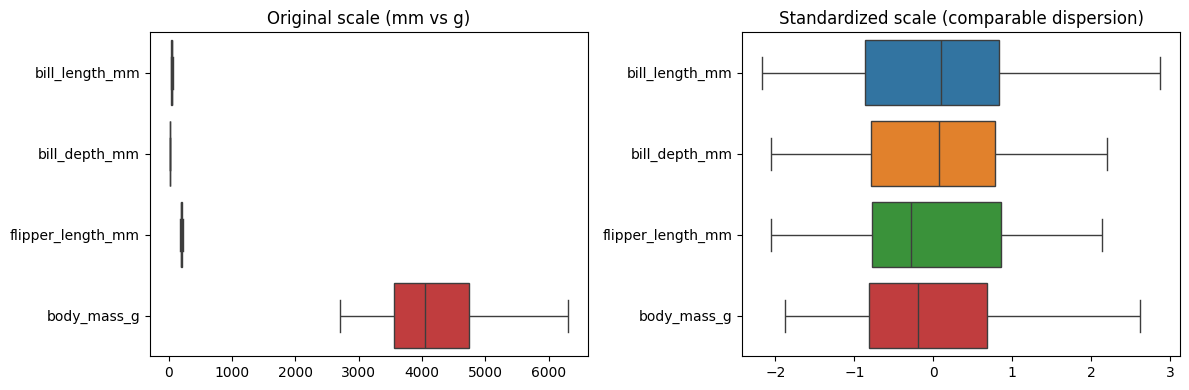

In [ ]:
from sklearn.preprocessing import StandardScaler

cols = ["bill_length_mm","bill_depth_mm", "flipper_length_mm", "body_mass_g"]

# Only the selected columns, without missing values
data = df[cols].dropna()

# Standardization (column-wise): mean 0, standard deviation 1
scaled = pd.DataFrame(
    StandardScaler().fit_transform(data),
    columns=cols,
    index=data.index
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=data, orient="h", ax=axes[0])
axes[0].set_title("Original scale (mm vs g)")

sns.boxplot(data=scaled, orient="h", ax=axes[1])
axes[1].set_title("Standardized scale (comparable dispersion)")

plt.tight_layout()
plt.show()

**Tip:** In the standardized plot, the variable that is more “variable” is the one where the box + whiskers are **relatively wider**.

### Question 2 – “I am interested in the composition of observations”

Now we are not asking **which variable is more variable** among penguins,  
but rather **for a specific penguin**, how the three features contribute proportionally to the observation.

**Question:**  
In the body structure of a given penguin, in what proportion do the following appear:

- bill length (`bill_length_mm`)
- bill depth (`bill_depth_mm`)
- flipper length (`flipper_length_mm`)?

In this case, the goal is the comparability of observations (rows), therefore we apply **row-wise normalization** (`Normalizer`).

After normalization, the row vector length becomes **1**,  
so the effect of “size” decreases and the **proportions** become more important.


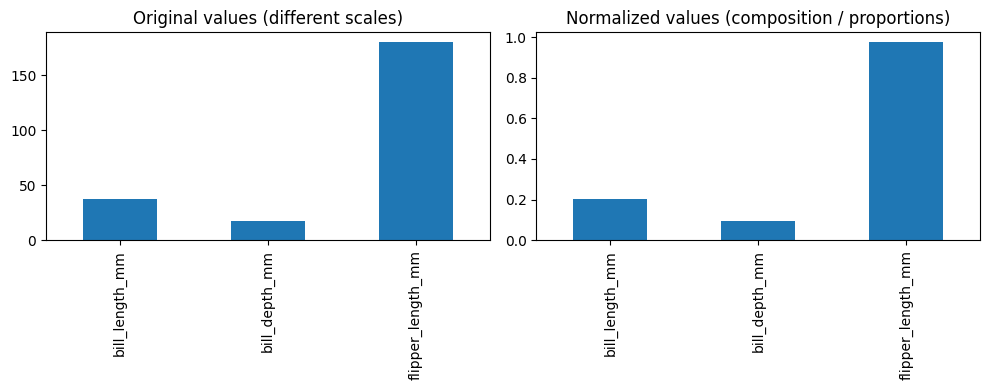

In [ ]:
from sklearn.preprocessing import Normalizer

cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]

# Select one penguin (1 row)
sample = df[cols].dropna().iloc[[10]]

# Row-wise normalization (L2 norm = 1)
normalized = pd.DataFrame(
    Normalizer(norm="l2").fit_transform(sample),
    columns=cols,
    index=sample.index
)

# (Optional) check: the length of the normalized row is indeed 1
# np.linalg.norm(normalized.values)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sample.T.plot(kind="bar", ax=axes[0], legend=False)
axes[0].set_title("Original values (different scales)")

normalized.T.plot(kind="bar", ax=axes[1], legend=False)
axes[1].set_title("Normalized values (composition / proportions)")

plt.tight_layout()
plt.show()


### 3D illustration: where do the penguins end up after normalization?

Based on the three body-size variables (mm), each penguin can be interpreted as a point in a 3D space.

- Before normalization, the points are freely distributed in the space.
- After normalization, the vector length of every point becomes **1**, therefore the points lie on the **surface of the unit sphere**.

Let us visualize this in a 3D figure (before–after), and also highlight a few random penguins.

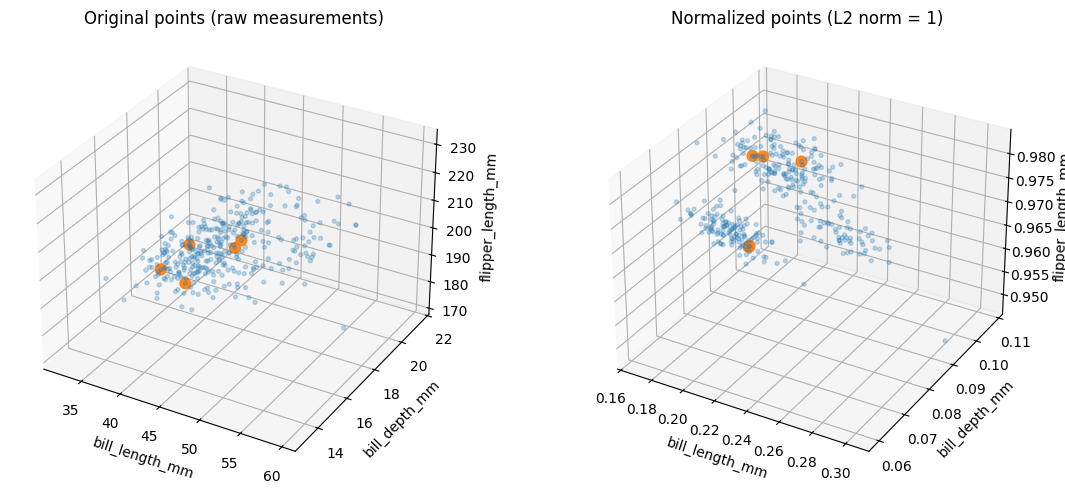

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import Normalizer

cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]

X = df[cols].dropna()

# Normalization
X_norm = pd.DataFrame(
    Normalizer(norm="l2").fit_transform(X),
    columns=cols,
    index=X.index
)

# Randomly select a few points to highlight
rng = np.random.default_rng(42)
highlight_idx = rng.choice(X.index, size=5, replace=False)

fig = plt.figure(figsize=(12, 5))

# --- Left: original space ---
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(X[cols[0]], X[cols[1]], X[cols[2]], s=8, alpha=0.25)
ax1.scatter(X.loc[highlight_idx, cols[0]],
            X.loc[highlight_idx, cols[1]],
            X.loc[highlight_idx, cols[2]],
            s=60, alpha=0.9)

ax1.set_title("Original points (raw measurements)")
ax1.set_xlabel(cols[0])
ax1.set_ylabel(cols[1])
ax1.set_zlabel(cols[2])

# --- Right: normalized space (surface of the unit sphere) ---
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(X_norm[cols[0]], X_norm[cols[1]], X_norm[cols[2]], s=8, alpha=0.25)
ax2.scatter(X_norm.loc[highlight_idx, cols[0]],
            X_norm.loc[highlight_idx, cols[1]],
            X_norm.loc[highlight_idx, cols[2]],
            s=60, alpha=0.9)

ax2.set_title("Normalized points (L2 norm = 1)")
ax2.set_xlabel(cols[0])
ax2.set_ylabel(cols[1])
ax2.set_zlabel(cols[2])

plt.tight_layout()
plt.show()

### What does the 3D plot show?

The plot on the left shows the penguins’ **original (raw) measurements** in 3D space.  
The distance between points is influenced both by the penguin’s **overall size** (how far it is from the origin)  
and by the **relative proportions** of the three body measurements.

### What changes after normalization (L2 norm = 1)?

In the plot on the right, each penguin has been divided by its own vector length,  
so every point lies on the **surface of the unit sphere**.

As a result, the effect of overall “size” disappears, and the difference between points is mainly determined by the **direction**:

nearby points represent similar **body proportions / profiles**,  
while distant points represent different profiles.

### Groupby + scaling together: global vs. species-wise standardization

The same variable (here: **body mass**) can be standardized in two different ways:

- **Globally**: all penguins together → we examine how much a penguin deviates from **all penguins**.
- **By species (groupby)**: separately within each species → we examine how much a penguin deviates from **its own species**.

**The key question:** what is the reference?

- If we want to compare **between species** (e.g., “which species is heavier?”), then global scaling is more natural.
- If we want to find **unusual individuals within a species** (e.g., “who is unusually light/heavy within a species?”), then species-wise scaling is appropriate.

Important: the two approaches answer **different questions**, so it is not a matter of “better or worse”, but **context-dependent**.

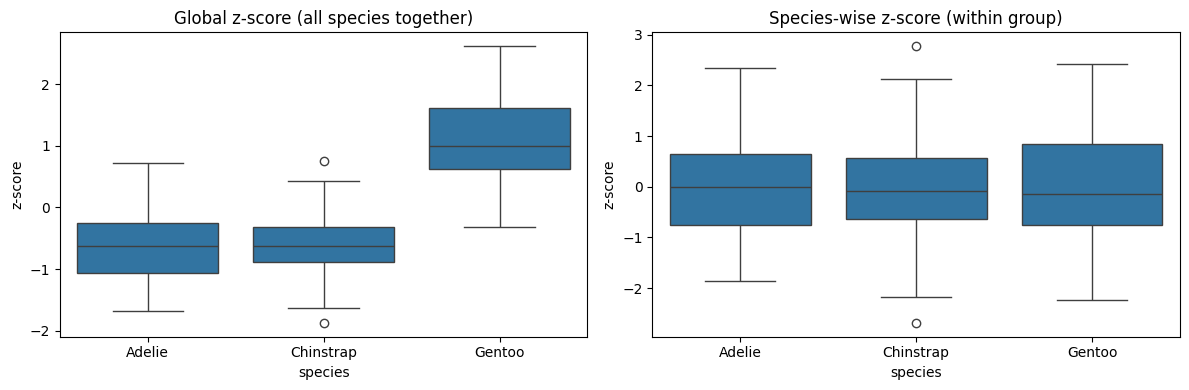

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load Penguins
df = sns.load_dataset("penguins").copy()

# Only the required columns, drop missing values
data = df[["species", "body_mass_g"]].dropna().copy()

# --- 1) Global standardization (all species together) ---
scaler_global = StandardScaler()
data["mass_z_global"] = scaler_global.fit_transform(data[["body_mass_g"]])

# --- 2) Species-wise standardization (groupby + transform) ---
def zscore(series: pd.Series) -> pd.Series:
    return (series - series.mean()) / series.std()

data["mass_z_by_species"] = data.groupby("species")["body_mass_g"].transform(zscore)

# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=data, x="species", y="mass_z_global", ax=axes[0])
axes[0].set_title("Global z-score (all species together)")
axes[0].set_ylabel("z-score")

sns.boxplot(data=data, x="species", y="mass_z_by_species", ax=axes[1])
axes[1].set_title("Species-wise z-score (within group)")
axes[1].set_ylabel("z-score")

plt.tight_layout()
plt.show()

### When does it distort, and when is it appropriate?

- **Global z-score can be misleading** if species already have different averages:  
  in this case, an entire species may fall into a “positive” or “negative” z-score range,  
  which reflects differences **between species** rather than variability **within a species**.

- **Species-wise z-score can be misleading** when the goal is to compare species:  
  since each species becomes its own “mean 0, standard deviation 1”,  
  the **differences between species averages disappear**.

Rule of thumb: first decide whether you want to compare to **everyone**, or to **one’s own group**.

### Exercises

## Introduction to the Diamonds dataset

The Diamonds dataset contains physical and quality characteristics of diamonds.  
Each row describes one diamond, and the columns record properties related to size, quality, and price.

The dataset is especially suitable for examining scaling, different orders of magnitude, and skewed distributions,  
because the price and size-related variables are on very different scales.

### Main columns

- **carat** – the weight of the diamond in carats  
- **cut** – the quality of the cut (Fair, Good, Very Good, Premium, Ideal)  
- **color** – the color quality (D–J, where D is the best)  
- **clarity** – the clarity category (e.g., SI1, VS2, IF)  
- **depth** – the depth ratio in percent  
- **table** – the width of the top surface in percent  
- **price** – the price in US dollars  
- **x** – length in millimeters  
- **y** – width in millimeters  
- **z** – height in millimeters  

In the dataset, the numerical variables are measured in different units  
and appear on different orders of magnitude, so without scaling  
their comparison can be misleading.



In [ ]:
df = sns.load_dataset("diamonds")
df.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### Exercise 1 – “Which variable is the most variable?” (standardization)

Select the following numerical columns:  
`carat`, `depth`, `table`, `price`, `x`, `y`, `z`

1. Create a boxplot of the selected variables on the **original scale**.
2. Standardize the variables using `StandardScaler`, then create a boxplot of the **standardized** variables as well.

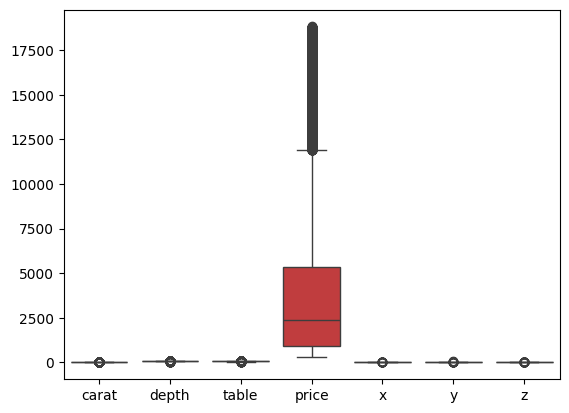

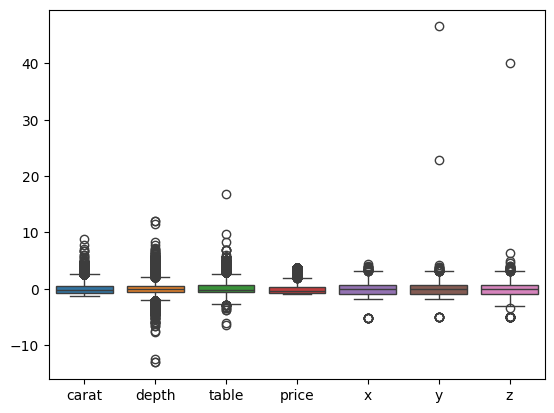

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = sns.load_dataset("diamonds")

cols = ["carat","depth","table","price","x","y","z"]
data = df[cols].dropna()

plt.figure()
sns.boxplot(data=data)
plt.show()

scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(data), columns=cols)

plt.figure()
sns.boxplot(data=scaled)
plt.show()

### Exercise 2 – Distance between two diamonds: what dominates without scaling?

1. Select the following columns:  
`carat`, `price`, `x`, `y`, `z`

2. Choose any two diamonds (two rows) and compute the **Euclidean distance** between them:
   - using the raw data (without scaling)
   - after standardization (`StandardScaler`)



In [2]:
import numpy as np

cols = ["carat","price","x","y","z"]
data = df[cols].dropna()

a = data.iloc[0].values
b = data.iloc[1].values

dist_raw = np.linalg.norm(a - b)
print(dist_raw)

from sklearn.preprocessing import StandardScaler
scaled = StandardScaler().fit_transform(data)

a_s = scaled[0]
b_s = scaled[1]

dist_scaled = np.linalg.norm(a_s - b_s)
print(dist_scaled)

0.19493588689617947
0.2204139878066451


### Exercise 3 – Effect of normalization: “size” vs. “proportions” (Normalizer)

In this exercise, we apply row-wise normalization, so the vector length of each diamond becomes **1**.  
The goal is that the distance is influenced less by overall “size” and more by the **relative proportions** of the variables.

1. Select the following columns:  
`carat`, `price`, `x`, `y`, `z`

2. Choose any two diamonds (two rows) and compute the **Euclidean distance** between them:
   - using the raw data (without normalization)
   - after row-wise normalization (`Normalizer(norm="l2")`)

In [3]:
from sklearn.preprocessing import Normalizer

cols = ["carat","price","x","y","z"]
data = df[cols].dropna()

a = data.iloc[0].values
b = data.iloc[1].values

dist_raw = np.linalg.norm(a - b)
print(dist_raw)

norm = Normalizer(norm="l2")
normed = norm.fit_transform(data)

a_n = normed[0]
b_n = normed[1]

dist_norm = np.linalg.norm(a_n - b_n)
print(dist_norm)

0.19493588689617947
0.000597775721069751
